# RFI Flagging Testing

Little notebook for testing the MomentRFI flagger on simulated and real data.

In [1]:

import numpy as np
import matplotlib.pyplot as plt
from sampler.reader import ObservationReader, ReflectionReader

import astropy.units as un
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams.update({
    "font.family": "serif"
})


In [2]:
observation_data = ObservationReader(
    'real_data/2026-09-04_03-32-26_obs.hdf5',
    temp_index_dict={'heated':1, 'ambient':0},
    frequency_lims=(68.5*un.MHz, 75.5*un.MHz),
    switch_buffer=5*un.s,
    )

In [3]:
print(np.unique(observation_data.states_array))

['antenna' 'heated_load' 'load' 'long_open' 'long_short' 'mask'
 'noise_diode' 'open' 'short']


In [4]:
from MomentRFI.MomentRFI import IterativeSurfaceFitter
from rfi_flagging.rfi_flagging import mask_by_state, flag_waterfall_momentRFI

In [ ]:

generic_flagger = IterativeSurfaceFitter(sigma_threshold=3,
                                         degree_freq=25,
                                         degree_time=3,
                                         verbose=True,

                                         )
# secondary_flagger = IterativeSurfaceFitter(sigm)


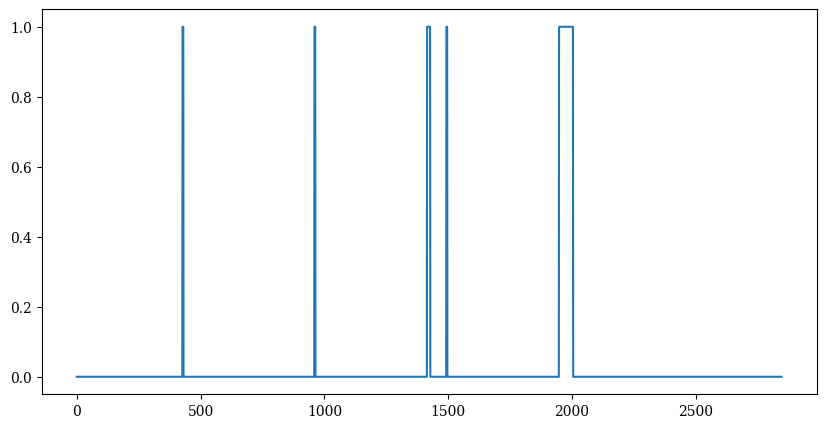

In [19]:
def generate_freq_prior_mask(freq_array,
                             mask_lim_list):
    freq_mask = np.zeros_like(freq_array)

    for mask_lim in mask_lim_list:
        mask = (freq_array >= mask_lim[0]) & (freq_array <= mask_lim[-1])
        freq_mask[mask] = 1
    return freq_mask

freq_prior = generate_freq_prior_mask(observation_data.freqs,
                                      mask_lim_list=[
                                          [68.23e6, 68.24e6],
                                          [69.55e6, 69.56e6],
                                          [70.86e6, 70.87e6],
                                          [71.98e6, 72.01e6],
                                          [72.17e6, 72.18e6],
                                          [73.29e6, 73.43e6],
                                      ])

plt.plot(freq_prior)

Round 0: surface fit (degree freq=25, time=3)
  Noise estimator: mad
  Number of basis terms: 104
  Iter  1: sigma=0.030126, flagged=137521 (8.9617%), changed=93323 (6.081524%)
  Iter  2: sigma=0.026327, flagged=157792 (10.2827%), changed=28899 (1.883244%)
  Iter  3: sigma=0.025704, flagged=162676 (10.6010%), changed=5528 (0.360240%)
  Iter  4: sigma=0.025573, flagged=163777 (10.6728%), changed=1221 (0.079568%)
  Iter  5: sigma=0.025545, flagged=164029 (10.6892%), changed=286 (0.018638%)
  Iter  6: sigma=0.025540, flagged=164079 (10.6924%), changed=68 (0.004431%)
  Iter  7: sigma=0.025542, flagged=164075 (10.6922%), changed=32 (0.002085%)
  Iter  8: sigma=0.025539, flagged=164093 (10.6934%), changed=24 (0.001564%)
  Iter  9: sigma=0.025540, flagged=164091 (10.6932%), changed=8 (0.000521%)
  Converged at iteration 9.

Final: 164091 pixels flagged (10.6932%)
  Round-0 sigma: 0.025540
  Gaussian expectation at 3.0-sigma: 0.2700%
  Actual / expected: 39.6x
Round 0: surface fit (degree freq

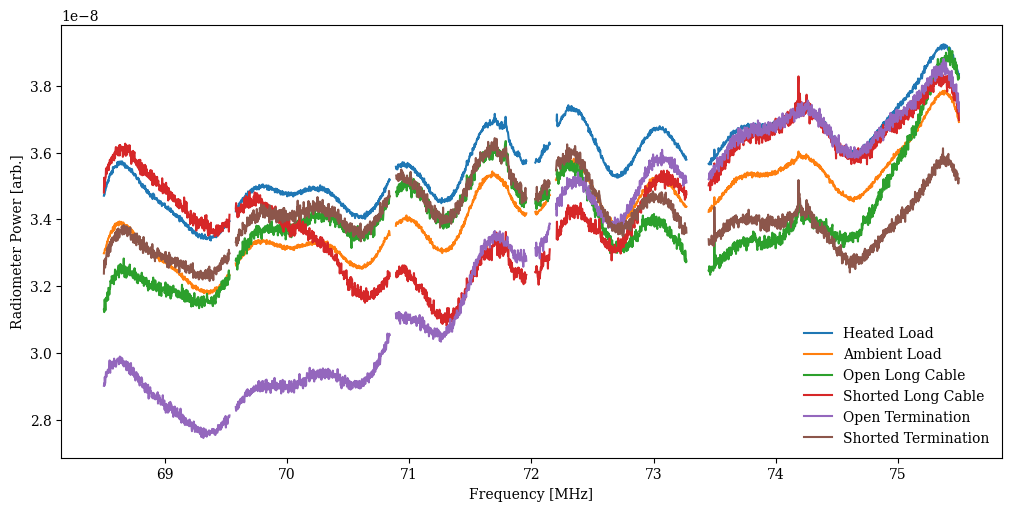

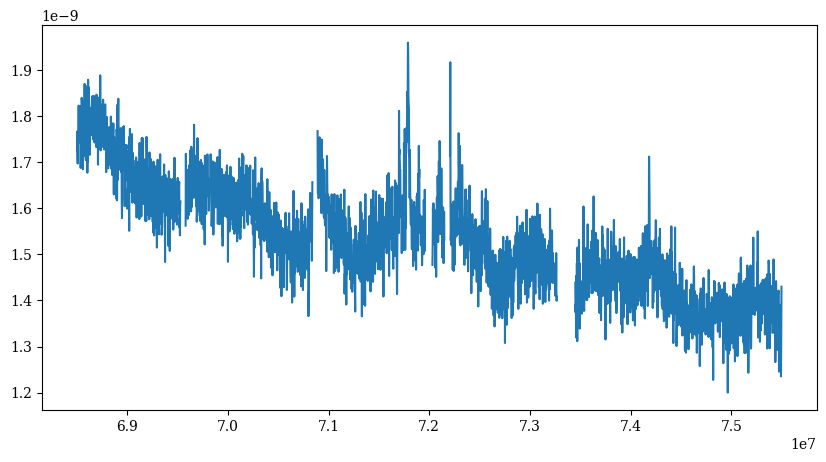

In [ ]:
def flag_state_by_state(
        observation_obj:ObservationReader,
        flagger_dict:dict,
        freq_channel_threshold:float=0.5,
        time_sample_threshold:float=0.5,
        expansion=(0,4),
        freq_prior=None,
):
    from scipy.ndimage import binary_dilation
    full_mask = np.zeros_like(observation_obj.data_waterfall)

    prior_masks = {}
    expansion = tuple(expansion)
    structure_shape = tuple(2 * n + 1 for n in expansion)
    structure = np.ones(structure_shape, dtype=bool)

    fig, axes = plt.subplots(layout='constrained')

    label_dict={'load': 'Ambient Load',
                'short': 'Shorted Termination',
                'open': 'Open Termination',
                'noise_diode': 'Noise Diode',
                'heated_load': 'Heated Load',
                'long_open':'Open Long Cable',
                'long_short':'Shorted Long Cable'}

    for state in np.unique(observation_obj.states_array):
        if state == 'mask':
            continue

        
        state_indices = np.where(observation_obj.states_array == state)[0]
        state_waterfall = np.take(observation_data.data_waterfall,
                                  state_indices, axis=0)
        state_flagger = flagger_dict[state]

        if freq_prior is not None:
            prior_mask = np.array([freq_prior for i in range(len(state_waterfall))])
        else:
            prior_mask = None
        #
        state_flags = state_flagger.fit(state_waterfall, prior_mask=prior_mask)
        state_flags = binary_dilation(state_flags, structure=structure)

        

        state_flags = state_flagger.fit(state_waterfall,
                                        prior_mask=state_flags)

        test_array = np.ma.array(data=state_waterfall,
                                 mask=state_flags)

        state_flags = np.asarray(state_flags, dtype=bool)
        structure = np.ones(structure_shape, dtype=bool)

        state_flags = binary_dilation(state_flags, structure=structure)
        test_array = np.ma.array(data=state_waterfall,
                                         mask=state_flags)
        print(structure)
        
        if state == 'heated_load':
            hl = np.mean(test_array, axis=0)
        if state == 'load':
            amb = np.mean(test_array, axis=0)
        if state == 'antenna' or state == 'noise_diode':
            continue
        label = label_dict[state]
        axes.plot(observation_obj.freqs / 1e6,
                      np.mean(test_array, axis=0),
                      label=label)
    axes.set_ylabel('Radiometer Power [arb.]')
    axes.set_xlabel('Frequency [MHz]')
    axes.legend(frameon=False)
    plt.show()

    gain_est = hl - amb

    plt.plot(observation_obj.freqs, gain_est)
    plt.show()


flag_state_by_state(
    observation_obj=observation_data,
    flagger_dict={'antenna':generic_flagger,
                                     'load':generic_flagger,
                                     'open':generic_flagger,
                                     'short':generic_flagger,
                                     'long_open':generic_flagger,
                                     'long_short':generic_flagger,
                                     'noise_diode':generic_flagger,
                                     'heated_load':generic_flagger},
    freq_prior=freq_prior   
)

[[ 0.00542453  0.00720296 -0.00370434 ... -0.00099899  0.02443193
   0.00172079]
 [ 0.01037844 -0.000715   -0.01321863 ...  0.01076792 -0.00191189
  -0.0026922 ]
 [-0.01252494  0.00794981 -0.01528124 ... -0.01829478  0.01900758
   0.00136446]
 ...
 [ 0.0016072   0.01400073 -0.0121349  ... -0.00243056  0.01033445
   0.01295158]
 [ 0.00464378 -0.00167983 -0.01665136 ...  0.01176658 -0.00776057
  -0.00256821]
 [-0.00481961  0.01061788 -0.02164687 ... -0.00617957  0.00879302
  -0.01903536]]


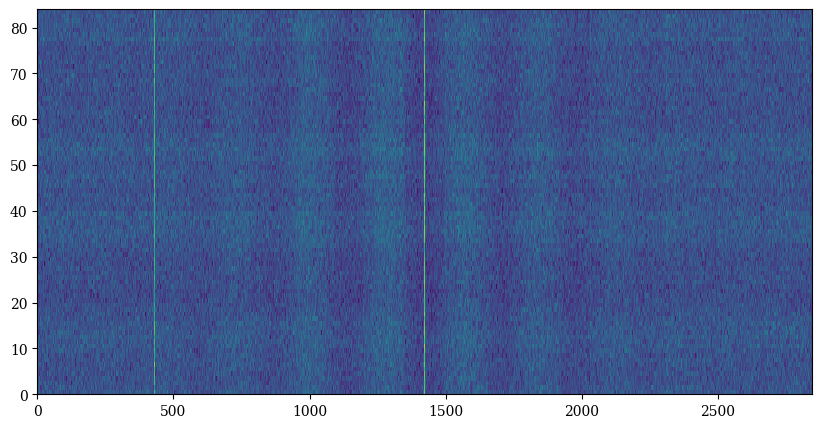

In [21]:
print(generic_flagger.residuals)

plt.pcolormesh(generic_flagger.residuals)

plt.show()

In [22]:

full_mask = mask_by_state(data=observation_data.data_waterfall,
                          state_labels=observation_data.states_array,
                          flag_dict={'antenna':antenna_flagger,
                                     'load':ambient_flagger,
                                     'open':ambient_flagger,
                                     'short':ambient_flagger,
                                     'long_open':ambient_flagger,
                                     'long_short':ambient_flagger,
                                     'noise_diode':ambient_flagger,
                                     'heated_load':ambient_flagger})

NameError: name 'antenna_flagger' is not defined

In [ ]:
print(observation_data.temperatures)

{'heated': array([407.97113604, 407.88043299, 407.79017846, ..., 406.581     ,
       406.581     , 406.581     ], shape=(5020,)), 'ambient': array([309.44433216, 309.451     , 309.451     , ..., 307.3216184 ,
       307.351     , 307.351     ], shape=(5020,))}


/var/folders/b7/pvn9mnl16d5fxvjs9z9l6p8c0000gp/T/ipykernel_47745/4076770200.py:19: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


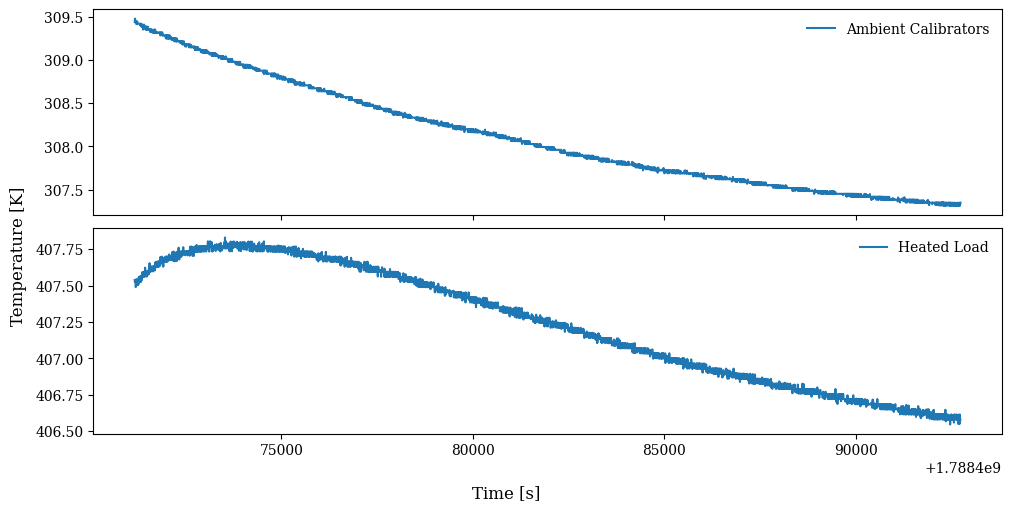

In [43]:
# plt.plot(observation_data.times,observation_data.temperatures['ambient'], label='Ambient Calibrators')
# plt.plot(observation_data.times,observation_data.temperatures['heated'], label='Heated Load')
# plt.legend(frameon=False)
# plt.show()

time_cut = 10
fig, axes = plt.subplots(layout='constrained', nrows=2,
                         sharex=True)
axes[0].plot(observation_data.times[time_cut:],
             observation_data.temperatures['ambient'][time_cut:], 
             label='Ambient Calibrators')
axes[1].plot(observation_data.times[time_cut:],
             observation_data.temperatures['heated'][time_cut:], 
             label='Heated Load')
axes[0].legend(frameon=False)
axes[1].legend(frameon=False)
fig.supylabel('Temperature [K]')
fig.supxlabel('Time [s]')
fig.show()


In [ ]:
print(observation_data.freqs)

[68000491.64208457 68002949.85250737 68005408.06293018 ...
 75994591.93706982 75997050.14749263 75999508.35791543]


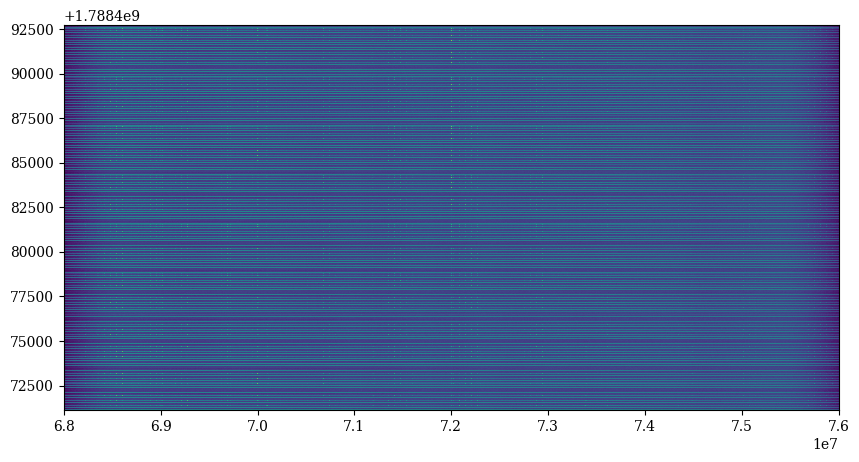

In [ ]:
plt.pcolormesh(observation_data.freqs,
               observation_data.times,
               np.log10(observation_data.data_waterfall))
plt.show()

In [ ]:
print(np.unique(observation_data.states_array))

['antenna' 'heated_load' 'load' 'long_open' 'long_short' 'noise_diode'
 'open' 'short']


In [ ]:
from rfi_flagging.rfi_flagging import mask_by_state